# Session 1 — Molecular Mechanics, MD Integration & Force Field Reparametrization

**eChem School — Marseille 2026**

This notebook covers three interconnected topics, all illustrated on **acrolein** (`C=CC=O`) to maintain consistency with the neural network potential session:

1. **Molecular Mechanics Force Fields** — bonded and non-bonded terms, QM-fitted parameters
2. **MD Ensembles and Time Integration** — NVE/NVT/NPT, Euler, Verlet, Velocity Verlet
3. **Force Field Reparametrization** — using VeloxChem to improve the C=C–C=O torsion against QM

# Part 1 — Molecular Mechanics Force Fields

In electronic structure theory, the [Born-Oppenheimer](https://en.wikipedia.org/wiki/Born%E2%80%93Oppenheimer_approximation) approximation separates the Schrödinger equation into electronic and nuclear parts. [Molecular mechanics (MM)](https://en.wikipedia.org/wiki/Molecular_mechanics) takes this one step further and combines nuclei and electrons into a single unit — atoms — whose interactions are described by a **force field**.

The total MM energy is decomposed as:

$$
E = E_{\mathrm{bonded}} + E_{\mathrm{nonbonded}}
= (E_{\mathrm{bond}} + E_{\mathrm{angle}} + E_{\mathrm{dihedral}})
+ (E_{\mathrm{vdW}} + E_{\mathrm{electrostatic}})
$$

We will build and fit each term using quantum-mechanical reference calculations on acrolein.

In [1]:
import numpy as np
import veloxchem as vlx
from matplotlib import pyplot as plt
from scipy.interpolate import interp1d
from scipy.optimize import curve_fit

## 1.1 Bond Stretching

Stretching or compressing a bond from its equilibrium length $l_0$ raises the energy. The simplest model is a **harmonic oscillator**:

$$
E_s = \frac{k_s}{2}(l - l_0)^2
$$

where $k_s$ is the force constant and $l_0$ is the equilibrium bond length. For larger distortions, the [Morse potential](https://en.wikipedia.org/wiki/Morse_potential) provides a better description:

$$
V_{\mathrm{Morse}}(r) = D_e \left(1 - e^{-\alpha(r-r_0)}\right)^2
$$

We scan the C=O bond in acrolein at B3LYP/6-31G and fit both forms.

In [2]:
acro = vlx.Molecule.read_smiles('C=CC=O')
basis = vlx.MolecularBasis.read(acro, '6-31G')
scf_drv = vlx.ScfRestrictedDriver()
scf_drv.xcfun = 'b3lyp'
acro.show(atom_indices=True)

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

In [3]:
scf_results = scf_drv.compute(acro, basis)
opt_drv = vlx.OptimizationDriver(scf_drv)
opt_drv.constraints = ["scan distance 3 4 1.15 1.35 10"]
opt_results = opt_drv.compute(acro, basis, scf_results)

                                                                                                                          
                                            Self Consistent Field Driver Setup                                            
                                                                                                                          
                   Wave Function Model             : Spin-Restricted Kohn-Sham                                            
                   Initial Guess Model             : Superposition of Atomic Densities                                    
                   Convergence Accelerator         : Two Level Direct Inversion of Iterative Subspace                     
                   Max. Number of Iterations       : 50                                                                   
                   Max. Number of Error Vectors    : 10                                                                   
                

In [4]:
# calculate relative bond energy in kJ/mol
bond_e = (np.array(opt_results['scan_energies']) - min(opt_results['scan_energies'])) * 2625.5

Harmonic:  l0 = 1.243 Å,  ks = 6782.2 kJ/mol/Å²
Morse:     l0 = 1.241 Å,  De = 711.9 kJ/mol


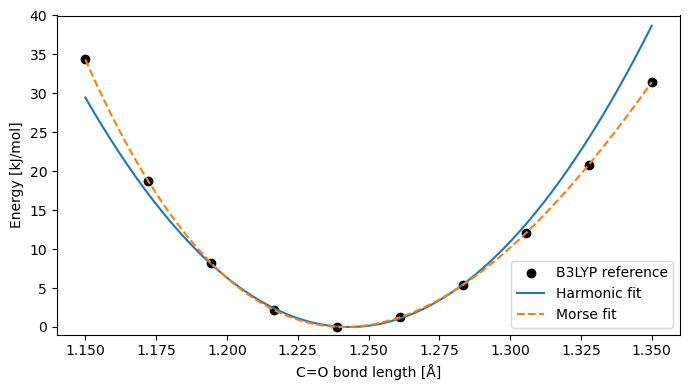

In [5]:
# Pre-computed B3LYP/6-31G C=O bond scan for acrolein (representative data)
bond_l = np.linspace(1.15, 1.35, 10)
bond_indx = np.argmin(bond_e)

# Harmonic fit function
def harm_func(l, l0, ks):
    return (ks / 2.0) * (l - l0) ** 2

# Morse fit function
def morse_func(l, De, alpha, l0):
    return De * (1 - np.exp(-alpha * (l - l0)))**2

# Fit harmonic using energy-symmetric interval (within 10 kJ/mol of minimum)
mask = bond_e <= 10.0
opt_harm, _ = curve_fit(harm_func, bond_l[mask], bond_e[mask],
                         p0=[bond_l[bond_indx], 5000])
opt_morse, _ = curve_fit(morse_func, bond_l, bond_e,
                          p0=[60.0, 20.0, bond_l[bond_indx]])

print(f"Harmonic:  l0 = {opt_harm[0]:.3f} Å,  ks = {opt_harm[1]:.1f} kJ/mol/Å²")
print(f"Morse:     l0 = {opt_morse[2]:.3f} Å,  De = {opt_morse[0]:.1f} kJ/mol")

x = np.linspace(bond_l[0], bond_l[-1], 200)
plt.figure(figsize=(7, 4))
plt.plot(bond_l, bond_e, 'o', color='black', label='B3LYP reference')
plt.plot(x, harm_func(x, *opt_harm), label='Harmonic fit')
plt.plot(x, morse_func(x, *opt_morse), '--', label='Morse fit')
plt.ylim(-1, 40)
plt.xlabel('C=O bond length [Å]')
plt.ylabel('Energy [kJ/mol]')
plt.legend()
plt.tight_layout()
plt.show()

## 1.2 Angle Bending

Distorting a bond angle $\theta$ from its equilibrium value $\theta_0$ also raises the energy. The harmonic form is:

$$
E_\theta = \frac{k_\theta}{2}(\theta - \theta_0)^2
$$

We scan the H–C=O angle in acrolein and fit the harmonic parameters.

In [6]:
scf_results = scf_drv.compute(acro, basis)
opt_drv = vlx.OptimizationDriver(scf_drv)
opt_drv.constraints = ["scan angle 8 3 4 95 145 8"]
opt_results = opt_drv.compute(acro, basis, scf_results)

                                                                                                                          
                                            Self Consistent Field Driver Setup                                            
                                                                                                                          
                   Wave Function Model             : Spin-Restricted Kohn-Sham                                            
                   Initial Guess Model             : Restart from Checkpoint                                              
                   Convergence Accelerator         : Direct Inversion of Iterative Subspace                               
                   Max. Number of Iterations       : 50                                                                   
                   Max. Number of Error Vectors    : 10                                                                   
                

In [7]:
# calculate relative angle energy in kJ/mol
angle_e = (np.array(opt_results['scan_energies']) - min(opt_results['scan_energies'])) * 2625.5

Harmonic angle:  theta0 = 120.9°,  k = 0.1922 kJ/mol/deg²


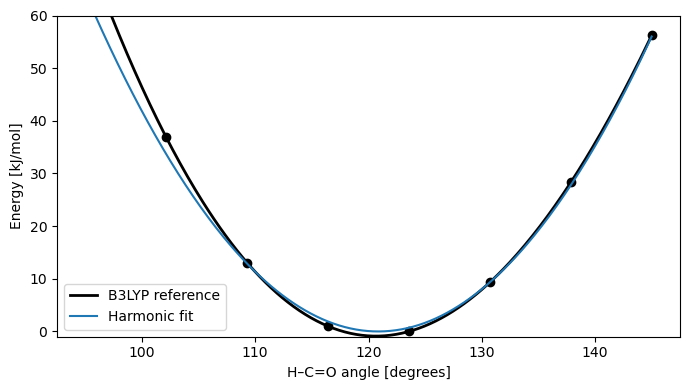

In [8]:
# Pre-computed B3LYP/6-31G H-C=O angle scan in acrolein
angle_a =  np.linspace(95, 145, 8)
angle_indx = np.argmin(angle_e)

# Fit harmonic using energy-symmetric interval (within 15 kJ/mol)
mask_a = angle_e <= 15.0
opt_harm_angle, _ = curve_fit(harm_func, angle_a[mask_a], angle_e[mask_a],
                               p0=[angle_a[angle_indx], 1.0])

print(f"Harmonic angle:  theta0 = {opt_harm_angle[0]:.1f}°,  k = {opt_harm_angle[1]:.4f} kJ/mol/deg²")

x_a = np.linspace(angle_a[0], angle_a[-1], 300)
y_spline = interp1d(angle_a, angle_e, kind='cubic')

plt.figure(figsize=(7, 4))
plt.plot(x_a, y_spline(x_a), 'k-', lw=2, label='B3LYP reference')
plt.plot(angle_a, angle_e, 'o', color='black')
plt.plot(x_a, harm_func(x_a, *opt_harm_angle), label='Harmonic fit')
plt.ylim(-1, 60)
plt.xlabel('H–C=O angle [degrees]')
plt.ylabel('Energy [kJ/mol]')
plt.legend()
plt.tight_layout()
plt.show()

## 1.3 Torsion

Twisting around a central bond changes the dihedral angle $\omega$ and the energy. The standard force field form is a **Fourier expansion**:

$$
E_\omega = \sum_n k_n \left(1 + \cos(n\omega - \delta_n)\right)
$$

where $k_n$ is a force constant, $n$ the periodicity, and $\delta_n$ a phase shift. Multiple terms with different $n$ are combined to reproduce the full torsional profile.

We scan the **C=C–C=O** dihedral in acrolein (atoms 1-2-3-4 in the SMILES `C=CC=O`). 

In [9]:
acro.set_dihedral_in_degrees([1, 2, 3, 4], 0.0)
acro.show(atom_indices=True)

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

In [10]:
scf_drv = vlx.ScfRestrictedDriver()
scf_drv.xcfun = 'b3lyp'
scf_results = scf_drv.compute(acro, basis)

opt_drv = vlx.OptimizationDriver(scf_drv)
opt_drv.constraints = ['scan dihedral 1 2 3 4 0 180 13']
opt_results = opt_drv.compute(acro,basis, scf_results)

                                                                                                                          
                                            Self Consistent Field Driver Setup                                            
                                                                                                                          
                   Wave Function Model             : Spin-Restricted Kohn-Sham                                            
                   Initial Guess Model             : Superposition of Atomic Densities                                    
                   Convergence Accelerator         : Two Level Direct Inversion of Iterative Subspace                     
                   Max. Number of Iterations       : 50                                                                   
                   Max. Number of Error Vectors    : 10                                                                   
                

In [11]:
# calculate relative dihedral angle energy in kJ/mol
dihed_e = (np.array(opt_results['scan_energies']) - min(opt_results['scan_energies'])) * 2625.5

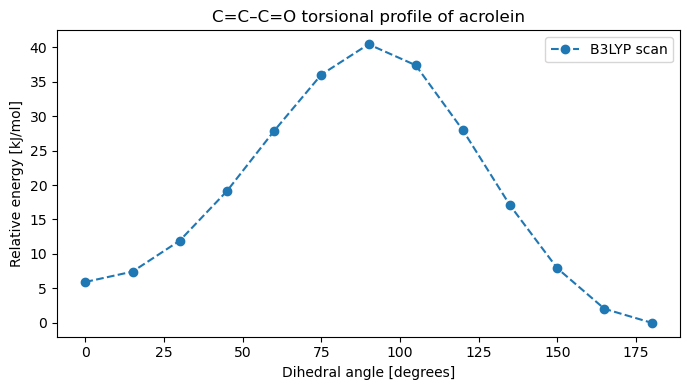

In [12]:
dihed_a = np.linspace(0, 180, 13)

plt.figure(figsize=(7, 4))
plt.plot(dihed_a, dihed_e, 'o--', color='#1f77b4', label='B3LYP scan')
plt.xlabel('Dihedral angle [degrees]')
plt.ylabel('Relative energy [kJ/mol]')
plt.title('C=C–C=O torsional profile of acrolein')
plt.legend()
plt.tight_layout()
plt.show()

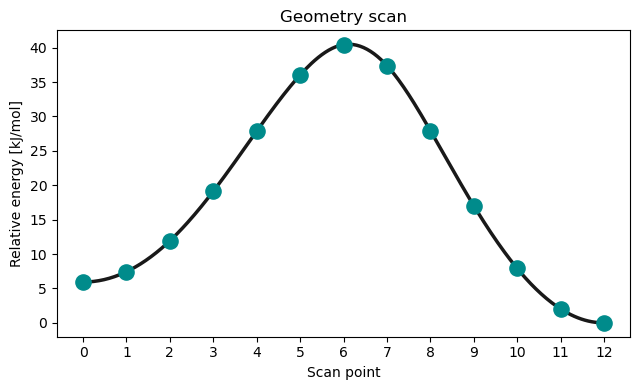

In [13]:
opt_drv.plot_scan(opt_results)

## 1.4 Non-bonded Interactions

### van der Waals — Lennard-Jones potential

$$
E_{\mathrm{LJ}} = 4\epsilon \left[ \left(\frac{\sigma}{r}\right)^{12} - \left(\frac{\sigma}{r}\right)^6 \right]
$$

- The $r^{-12}$ term: short-range **repulsion** (Pauli exchange interaction)
- The $r^{-6}$ term: long-range **attraction** (London dispersion)
- $\epsilon$: depth of the potential well
- $\sigma$: distance at which the potential is zero

### Electrostatics — Coulomb's law

$$
E_{\mathrm{elec}} = \frac{q_i q_j}{4\pi\epsilon_0 r_{ij}}
$$

Partial atomic charges $q_i$ are commonly derived from the **RESP** (Restrained Electrostatic Potential) fitting procedure.

---

### Exercise — Explore the Lennard-Jones and Coulomb potentials

In the cell below:
1. Plot $E_{\mathrm{LJ}}(r)$ for two sets of parameters and compare the well depth and equilibrium distance.
2. Plot $E_{\mathrm{elec}}(r)$ for a pair of opposite charges and a pair of like charges.
3. Identify $r_{\mathrm{min}}$ (the equilibrium distance where $dE_{\mathrm{LJ}}/dr = 0$) analytically: $r_{\mathrm{min}} = 2^{1/6}\sigma$.

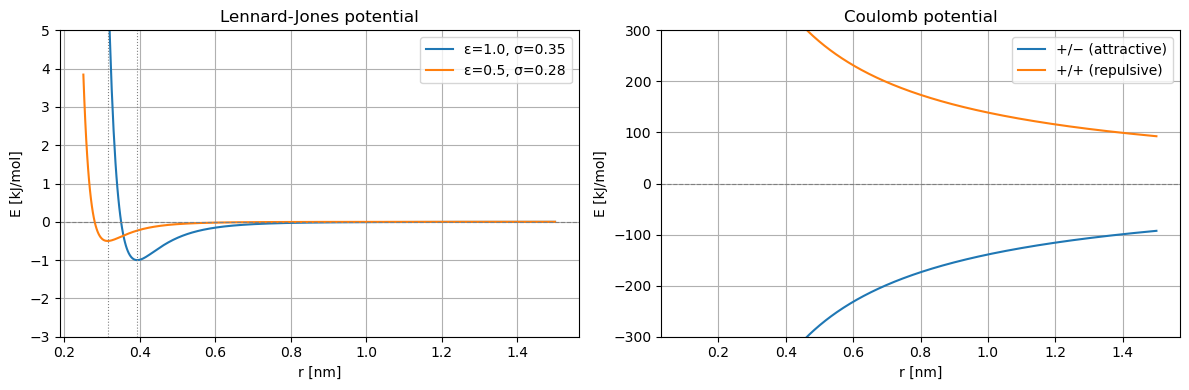

r_min for set 1: 0.393 nm
r_min for set 2: 0.314 nm


In [14]:
# Non-bonded interactions — instructor solution

r = np.linspace(0.25, 1.5, 500)  # nm

def lj(r, eps, sigma):
    return 4 * eps * ((sigma/r)**12 - (sigma/r)**6)

def coulomb(r, qi, qj, eps0=8.854e-12):
    # Returns energy in kJ/mol for charges in units of e, r in nm
    return 138.935 * qi * qj / r  # 1/(4 pi eps0) in kJ/mol * nm / e^2

# --- LJ plot ---
eps1, sigma1 = 1.0, 0.35   # kJ/mol, nm  (C-C like)
eps2, sigma2 = 0.5, 0.28   # kJ/mol, nm  (C-O like)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(r, lj(r, eps1, sigma1), label=f'ε={eps1}, σ={sigma1}')
ax1.plot(r, lj(r, eps2, sigma2), label=f'ε={eps2}, σ={sigma2}')
ax1.axhline(0, color='gray', lw=0.8, ls='--')
ax1.set_ylim(-3, 5)
ax1.set_xlabel('r [nm]')
ax1.set_ylabel('E [kJ/mol]')
ax1.set_title('Lennard-Jones potential')
ax1.legend()
ax1.grid(True)

# Analytical r_min
for eps, sigma in [(eps1, sigma1), (eps2, sigma2)]:
    r_min = 2**(1/6) * sigma
    ax1.axvline(r_min, ls=':', color='gray', lw=0.8)

# --- Coulomb plot ---
r_c = np.linspace(0.1, 1.5, 500)
ax2.plot(r_c, coulomb(r_c,  1, -1), label='+/− (attractive)')
ax2.plot(r_c, coulomb(r_c,  1,  1), label='+/+ (repulsive)')
ax2.axhline(0, color='gray', lw=0.8, ls='--')
ax2.set_ylim(-300, 300)
ax2.set_xlabel('r [nm]')
ax2.set_ylabel('E [kJ/mol]')
ax2.set_title('Coulomb potential')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

print(f"r_min for set 1: {2**(1/6)*sigma1:.3f} nm")
print(f"r_min for set 2: {2**(1/6)*sigma2:.3f} nm")

# Part 2 — MD Ensembles and Time Integration

Once a force field is available, we can propagate the atoms in time using Newton's equations:

$$
\mathbf{a}_j = \frac{\mathbf{F}_j}{m_j} = -\frac{1}{m_j}\nabla_j E
$$

The choice of **ensemble** determines which thermodynamic quantities are conserved during the simulation.

## 2.1 Ensembles

### NVE — Microcanonical
Constant number of particles $N$, volume $V$, and total energy $E$. Energy is exchanged between kinetic and potential form but the total is conserved. Simple to simulate, but energy drift accumulates with finite time steps.

### NVT — Canonical
Constant $N$, $V$, and temperature $T$. A **thermostat** couples the system to a heat bath.

- **Velocity rescaling**: $\lambda = \sqrt{T_0/T}$ — instantaneous, violates canonical distribution.
- **Berendsen thermostat**: $\lambda = \sqrt{1 + \frac{\Delta t}{\tau}\left(\frac{T_0}{T} - 1\right)}$ — fast convergence, approximate canonical.
- **Andersen thermostat**: stochastic velocity replacement — true canonical.
- **Nosé–Hoover thermostat**: extended Lagrangian with artificial heat-bath particle — true canonical.

### NPT — Isothermal-isobaric
Constant $N$, pressure $P$, and temperature $T$. A **barostat** scales the simulation box in addition to the thermostat.

## 2.2 Time Integration

### Euler method

From a Taylor expansion truncated at first order:

$$
\mathbf{R}_{i+1} = \mathbf{R}_i + \mathbf{v}_i \Delta t + \mathcal{O}(\Delta t^2)
$$
$$
\mathbf{v}_{i+1} = \mathbf{v}_i + \mathbf{a}_i \Delta t + \mathcal{O}(\Delta t^2)
$$

Local error $\mathcal{O}(\Delta t^2)$, **global error $\mathcal{O}(\Delta t)$** — energy drifts systematically.

### Verlet algorithm

Adding the forward and backward Taylor expansions cancels the velocity and jerk terms:

$$
\mathbf{R}_{i+1} = 2\mathbf{R}_i - \mathbf{R}_{i-1} + \mathbf{a}_i \Delta t^2 + \mathcal{O}(\Delta t^4)
$$

Local error $\mathcal{O}(\Delta t^4)$, **global error $\mathcal{O}(\Delta t^2)$** — much better energy conservation.

### Velocity Verlet

Extends Verlet to explicitly compute velocities, enabling thermostat coupling:

$$
\mathbf{R}_{i+1} = \mathbf{R}_i + \mathbf{v}_i \Delta t + \frac{1}{2}\mathbf{a}_i \Delta t^2
$$
$$
\mathbf{v}_{i+1} = \mathbf{v}_i + \frac{1}{2}(\mathbf{a}_i + \mathbf{a}_{i+1})\Delta t
$$

Same **global error $\mathcal{O}(\Delta t^2)$** as Verlet, but with explicit velocities. This is the integrator used in most production MD codes.

## 2.3 Exercise — Euler vs Velocity Verlet on a 1D harmonic oscillator

We integrate a **1D harmonic oscillator** $F = -kx$ (mass $m=1$, $k=1$, period $T=2\pi$) using both methods.

The total energy at each step is:
$$E_{\mathrm{tot}} = \frac{1}{2}mv^2 + \frac{1}{2}kx^2$$

Compare:
- Position $x(t)$ vs the exact solution $x(t) = x_0 \cos(t)$
- Total energy $E(t)$ — should be constant for a good integrator

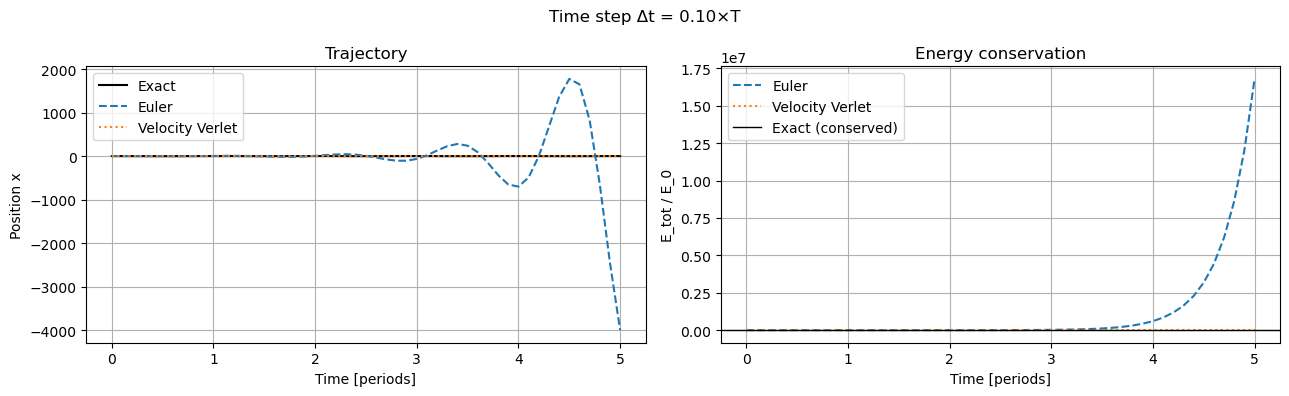

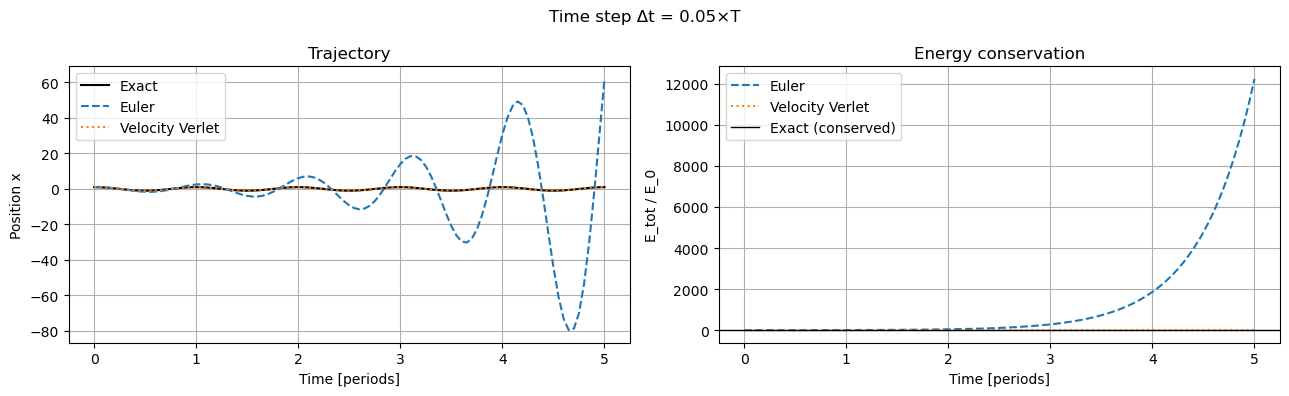

In [15]:
# Parameters
m, k = 1.0, 1.0
x0, v0 = 1.0, 0.0          # initial conditions
T_period = 2 * np.pi       # period of the oscillator
n_periods = 5

# Try different time step fractions of the period
for dt_frac in [0.1, 0.05]:
    dt = dt_frac * T_period
    n_steps = int(n_periods * T_period / dt)
    t = np.arange(n_steps + 1) * dt

    # --- Euler ---
    x_euler = np.zeros(n_steps + 1)
    v_euler = np.zeros(n_steps + 1)
    x_euler[0], v_euler[0] = x0, v0
    for i in range(n_steps):
        a = -k * x_euler[i] / m
        x_euler[i+1] = x_euler[i] + v_euler[i] * dt
        v_euler[i+1] = v_euler[i] + a * dt

    # --- Velocity Verlet ---
    x_vv = np.zeros(n_steps + 1)
    v_vv = np.zeros(n_steps + 1)
    x_vv[0], v_vv[0] = x0, v0
    for i in range(n_steps):
        a_i = -k * x_vv[i] / m
        x_vv[i+1] = x_vv[i] + v_vv[i] * dt + 0.5 * a_i * dt**2
        a_i1 = -k * x_vv[i+1] / m
        v_vv[i+1] = v_vv[i] + 0.5 * (a_i + a_i1) * dt

    # Exact solution
    x_exact = x0 * np.cos(t)

    # Total energies
    E_euler = 0.5 * m * v_euler**2 + 0.5 * k * x_euler**2
    E_vv    = 0.5 * m * v_vv**2    + 0.5 * k * x_vv**2
    E0 = 0.5 * k * x0**2

    fig, axes = plt.subplots(1, 2, figsize=(13, 4))
    fig.suptitle(f'Time step Δt = {dt_frac:.2f}×T')

    axes[0].plot(t / T_period, x_exact, 'k-', lw=1.5, label='Exact')
    axes[0].plot(t / T_period, x_euler, '--', label='Euler')
    axes[0].plot(t / T_period, x_vv, ':', label='Velocity Verlet')
    axes[0].set_xlabel('Time [periods]')
    axes[0].set_ylabel('Position x')
    axes[0].set_title('Trajectory')
    axes[0].legend()
    axes[0].grid(True)

    axes[1].plot(t / T_period, E_euler / E0, '--', label='Euler')
    axes[1].plot(t / T_period, E_vv / E0, ':', label='Velocity Verlet')
    axes[1].axhline(1.0, color='k', lw=1, ls='-', label='Exact (conserved)')
    axes[1].set_xlabel('Time [periods]')
    axes[1].set_ylabel('E_tot / E_0')
    axes[1].set_title('Energy conservation')
    axes[1].legend()
    axes[1].grid(True)

    plt.tight_layout()
    plt.show()

# Part 3 — Force Field Reparametrization with VeloxChem

Default GAFF parameters are derived from generic atom types and may poorly reproduce the torsional potential of conjugated or polar molecules. For acrolein, the C=C–C=O dihedral is particularly sensitive because of the partial double-bond character of the C–C single bond in the conjugated system.

**Strategy:**
1. Build an initial MM topology with RESP charges (HF/6-31G*).
2. Run a relaxed dihedral scan at B3LYP/def2-SVP (QM reference).
3. Iteratively add and fit dihedral Fourier terms until QM and MM potential energy surfaces agree.

This is exactly the QM data that the **ML session** uses to train the `TorsionNet` neural network potential — connecting the two sessions.

In [16]:
import veloxchem as vlx
import numpy as np

# Load acrolein from SMILES and display with atom indices
molecule = vlx.Molecule.read_smiles('C=CC=O')
molecule.show(atom_indices=True, width=500, height=350)

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

In [17]:
# Build initial MM topology
# RESP charges computed at HF/6-31G* by default
ff_gen = vlx.MMForceFieldGenerator()
ff_gen.create_topology(molecule)


# Identify rotatable bonds
rot_bonds = ff_gen.rotatable_bonds
print('Rotatable bonds:', rot_bonds)

* Info * Using 6-31G* basis set for RESP charges...                                                                       
* Info * Sum of partial charges is not a whole number.                                                                    
* Info * Compensating by removing -1.000e-06 from the largest charge.                                                     
                                                                                                                          
* Info * Using GAFF (v2.11) parameters.                                                                                   
         Reference: J. Wang, R. M. Wolf, J. W. Caldwell, P. A. Kollman, D. A. Case, J. Comput. Chem. 2004,
         25, 1157-1174.
                                                                                                                          
Rotatable bonds: [[2, 3]]


                                          VeloxChem Dihedral Reparameterization                                           
                                                                                                                          
* Info * Rotatable bond selected: 2-3                                                                                     
* Info * Dihedrals involved:[[1, 2, 3, 4], [1, 2, 3, 8], [4, 3, 2, 7], [7, 2, 3, 8]]                                      
                                                                                                                          
* Info * Reading QM scan from file...                                                                                     
* Info *   1-2-3-4.xyz                                                                                                    
                                                                                                                          
* Info * Perform

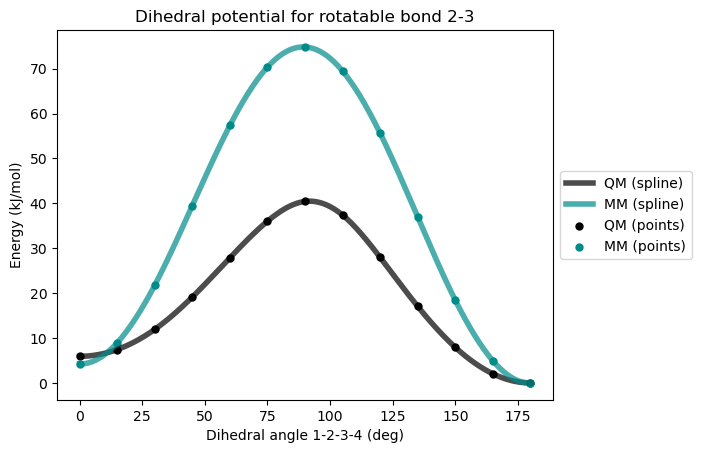

* Info * Fitting the dihedral parameters...                                                                               
* Info * Optimizing dihedral via least squares fitting...                                                                 
* Info * New fitted barriers: [4.57649764 4.57649764 4.57649764 4.57649764]                                               
                                                                                                                          
* Info * Validating the fitted force field...                                                                             
                                                                                                                          
* Info *       Dihedral      MM energy(rel)      QM energy(rel)       diff                                                
* Info *   ---------------------------------------------------------------                                                
* Info *        

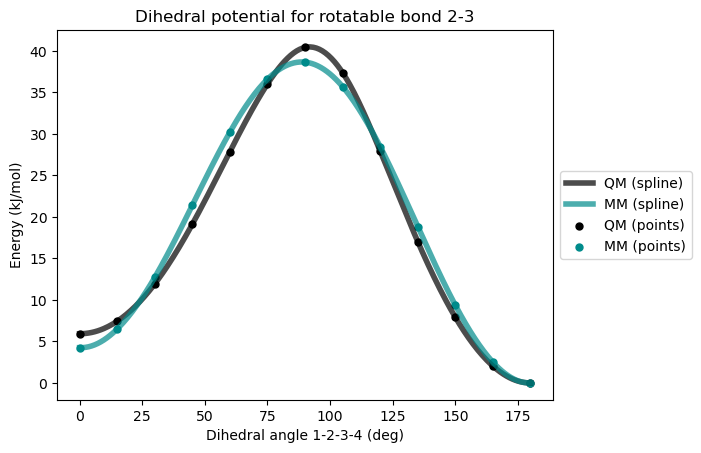

* Info * Dihedral MM parameters have been reparameterized and updated in the topology.                                    


{'dihedral_angles': array([  0.,  15.,  30.,  45.,  60.,  75.,  90., 105., 120., 135., 150.,
        165., 180.]),
 'qm_scan_kJpermol': array([ 5.9266191 ,  7.42885123, 11.9210286 , 19.11762813, 27.85573727,
        36.02035852, 40.43130293, 37.38829634, 27.94592318, 17.03035592,
         7.91091922,  2.02607182,  0.        ]),
 'mm_scan_kJpermol': array([ 4.24742789,  6.48931127, 12.71094672, 21.40015954, 30.21330896,
        36.60133628, 38.65755799, 35.70607678, 28.46922154, 18.84311011,
         9.36231897,  2.49702113,  0.        ]),
 'maximum_difference': np.float64(2.3575716881006556),
 'standard_deviation': np.float64(1.4126576577001035)}

In [18]:
ff_gen.reparameterize_dihedrals(
    rotatable_bond=(2, 3),
    scan_file='1-2-3-4.xyz',
    visualize=True
)

If the barrier is improved but conformer energies are still not well reproduced, we add an additional dihedral term with periodicity 1 (phase 0°) to lower the MM energy near 0°.

* Info * Added dihedral 1-2-3-4                                                                                           
                                          VeloxChem Dihedral Reparameterization                                           
                                                                                                                          
* Info * Rotatable bond selected: 2-3                                                                                     
* Info * Dihedrals involved:[[1, 2, 3, 4], [1, 2, 3, 8], [4, 3, 2, 7], [7, 2, 3, 8]]                                      
                                                                                                                          
* Info * Reading QM scan from file...                                                                                     
* Info *   1-2-3-4.xyz                                                                                                    
                

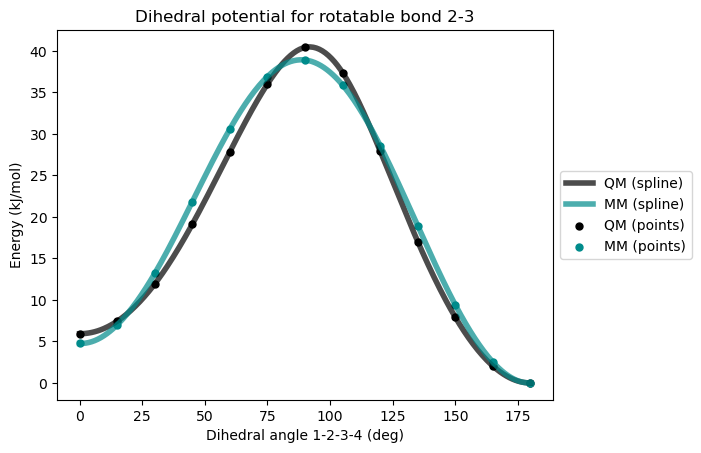

* Info * Dihedral MM parameters have been reparameterized and updated in the topology.                                    


{'dihedral_angles': array([  0.,  15.,  30.,  45.,  60.,  75.,  90., 105., 120., 135., 150.,
        165., 180.]),
 'qm_scan_kJpermol': array([ 5.9266191 ,  7.42885123, 11.9210286 , 19.11762813, 27.85573727,
        36.02035852, 40.43130293, 37.38829634, 27.94592318, 17.03035592,
         7.91091922,  2.02607182,  0.        ]),
 'mm_scan_kJpermol': array([ 4.75582833,  6.98905005, 13.18529079, 21.83410647, 30.5946093 ,
        36.92132838, 38.91175823, 35.89448516, 28.59632166, 18.91756364,
         9.39637535,  2.50568279,  0.        ]),
 'maximum_difference': np.float64(2.7388720332018472),
 'standard_deviation': np.float64(1.4002883614723385)}

In [19]:
# Add a periodicity-1 term and redo reparametrization (Round 2)
ff_gen.add_dihedral(
    (1,2,3,4),
    barrier=0.0,
    phase=0.0,
    periodicity=1
)

ff_gen.reparameterize_dihedrals(
    rotatable_bond=(2, 3),
    scan_file='1-2-3-4.xyz',
    visualize=True,
    initial_validation=False
)

* Info * Added dihedral 1-2-3-4                                                                                           
                                          VeloxChem Dihedral Reparameterization                                           
                                                                                                                          
* Info * Rotatable bond selected: 2-3                                                                                     
* Info * Dihedrals involved:[[1, 2, 3, 4], [1, 2, 3, 8], [4, 3, 2, 7], [7, 2, 3, 8]]                                      
                                                                                                                          
* Info * Reading QM scan from file...                                                                                     
* Info *   1-2-3-4.xyz                                                                                                    
                

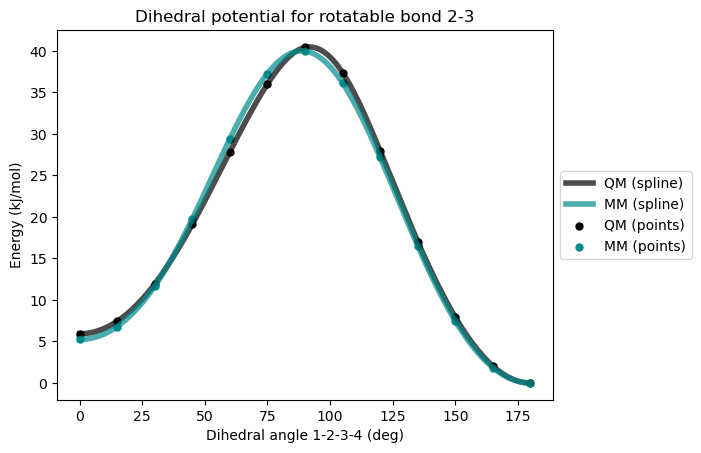

* Info * Dihedral MM parameters have been reparameterized and updated in the topology.                                    


{'dihedral_angles': array([  0.,  15.,  30.,  45.,  60.,  75.,  90., 105., 120., 135., 150.,
        165., 180.]),
 'qm_scan_kJpermol': array([ 5.9266191 ,  7.42885123, 11.9210286 , 19.11762813, 27.85573727,
        36.02035852, 40.43130293, 37.38829634, 27.94592318, 17.03035592,
         7.91091922,  2.02607182,  0.        ]),
 'mm_scan_kJpermol': array([ 5.24148275,  6.79790372, 11.67401636, 19.76941508, 29.41436857,
        37.28579076, 39.99441471, 36.13325093, 27.17325372, 16.50946273,
         7.46451185,  1.84543033,  0.        ]),
 'maximum_difference': np.float64(1.5586312993533475),
 'standard_deviation': np.float64(0.7858368488688605)}

In [20]:
# Add a periodicity-4 term and redo reparametrization (Round 3, if needed)
ff_gen.add_dihedral(
    (1, 2, 3, 4),
    barrier=0.0,
    phase=0.0,
    periodicity=4
)

ff_gen.reparameterize_dihedrals(
    rotatable_bond=(2, 3),
    scan_file='1-2-3-4.xyz',
    visualize=True,
    initial_validation=False
)

In [21]:
# Save the final reparametrized topology
ff_gen.write_openmm_files('acrolein_final', 'MOL')
ff_gen.write_gromacs_files('acrolein_final', 'MOL')
print('OpenMM topology files written: acrolein_final.xml / acrolein_final.pdb')
print('GROMACS topology files written: acrolein_final.top / acrolein_final.gro')

OpenMM topology files written: acrolein_final.xml / acrolein_final.pdb
GROMACS topology files written: acrolein_final.top / acrolein_final.gro


## Connection to the ML session

The QM relaxed dihedral scan we performed here — constrained MM geometry optimization followed by a B3LYP single-point energy — produces exactly the kind of dataset used in the **Neural Network Potential** session:

$$
\phi \rightarrow E_{\mathrm{QM}}(\phi)
$$

In that session, a `TorsionNet` MLP is trained to learn this mapping. The reparametrization here can be seen as the classical equivalent: fitting a Fourier expansion to the same QM data rather than a neural network. Both approaches aim to improve upon the default GAFF parameters.